# Part C2 comparison of in-situ data to observed values

## Steps:
3. Allocate observed values to the observation points
4. Develop a function to translate from observed to in-situ


In [36]:
del dfg

In [22]:
# ---  dependencies --- 

import datacube
import numpy as np
import xarray as xr
import scipy as sp
import gc
import json
from   scipy import stats
import pandas as pd     #for dates
from   odc.ui import image_aspect
from   deafrica_tools.plotting import rgb 
import geopandas as gpd
#from   shapely.geometry import Point
#import seaborn as sns
#from   odc.geo.geom import Geometry

# used in some visualisation for debugging
#dc = datacube.Datacube(app='DoinWhatImdoin') #testing what difference the 'app' value makes...

In [97]:
# --- pathnames 
# results files are stored in my space for now
results_directory = '/home/jovyan/deafrica_water_quality/wq_results/'
WP12              = '/home/jovyan/dev/deafrica_water_quality/WP1.2/'
WP22              = '/home/jovyan/dev/deafrica_water_quality/WP2.2/'
data_directory    = '/home/jovyan/dev/deafrica_water_quality/src/water_quality/data/'
all_results_filename    = 'wq_raw'
annual_results_filename  = 'annsummary'
parta_results_filename   = '22A'
partc_results_filename   = '22C'
distributions_filename = 'measurment_distributions.nc'
lookup_table_filename  = 'targ_ref_lookup.csv'
np_parameters_filename = 'normalisation_parameters.csv'


In [24]:
# --- run code for functions that are called
%run /home/jovyan/dev/deafrica_water_quality/WP2.2/_WP2.2_functions.py   
%run /home/jovyan/dev/deafrica_water_quality/WP1.2/_WQ_functions.py

## 1. Load reference data

In [25]:
# functions from fang to read data

def flag_type(flag):
    if pd.isna(flag):
        return "normal"
    elif "<" in str(flag):
        return "below"
    elif ">" in str(flag):
        return "above"
    else:
        return "normal"
        
def read_insitu(parameter):

    df = pd.read_csv(f"samples_{parameter}.csv")

    df["datetime"]  = pd.to_datetime(df['Sample Date'] + " " + df['Sample Time'], errors='coerce')
    #df = df[df["Station Identifier"].str.contains("Lake Victoria")]
    df['flag_type'] = df['Value Flags'].apply(flag_type)

    units = df['Unit'].unique()
    if len(units)>1:
        to_update = df.Unit.str.startswith('mg')
        df.loc[to_update, 'Value'] = df.loc[to_update, 'Value']/1000.
        df.loc[to_update, 'Unit'] = df.loc[to_update, 'Unit'].str.replace(r'^m', 'µ', regex=True)
        units = df['Unit'].unique()
        if len(units)>1:
            print(f"Multiple units found for {parameter}: {units}")
    return df

In [26]:
# read in the data for chla and tss
chla = read_insitu('Chl-a')
tss = read_insitu('tss')
data={}
data['chla'],data['tss'] = chla,tss

In [27]:
# insert a unique? observation number
chla.insert(0,'observation',chla.index)
tss.insert(0,'observation',tss.index)

In [28]:
# get a unique list of stations and count the number of observations ...

stations = pd.concat(
        (chla[['GEMS Station Number','Latitude','Longitude','Station Identifier']].drop_duplicates(),
         tss [['GEMS Station Number','Latitude','Longitude','Station Identifier']].drop_duplicates(),
        )).drop_duplicates()

stations = stations.set_index('GEMS Station Number')
#tss[['GEMS Station Number','Latitude','Longitude']].drop_duplicates()),axis=0).head()
#rename(columns={'flag_type':'sample_count'})
#tss.groupby('GEMS Station Number').count()

# for each station count the tss and chla observations, join to a single file, convert nans to zeros, convert to integers ... (!)

stations['count_total'] = 0
for mmt in 'chla','tss' :
    stations = stations.join(
        pd.DataFrame(data[mmt].groupby('GEMS Station Number').count()['flag_type']).\
            rename(columns={'flag_type': mmt+'_count'}))
    stations.loc[pd.isnull(stations[mmt+'_count']),mmt+'_count'] = 0
    stations[mmt+'_count']  = \
        stations[mmt+'_count'].values.astype('int')
    stations.rename(inplace=True,columns={mmt+'_count' : 'count_'+mmt})
    stations['count_total'] = stations['count_total'] + stations['count_'+mmt]
    stations = stations.join(
        pd.DataFrame(data[mmt].groupby('GEMS Station Number')['Sample Date'].min()).rename(columns={'Sample Date' : 'date_start_'+mmt}))
    stations = stations.join(
        pd.DataFrame(data[mmt].groupby('GEMS Station Number')['Sample Date'].max()).rename(columns={'Sample Date' : 'date_end_'+mmt}))
    stations.loc[pd.isnull(stations['date_start_'+mmt]),'date_start_'+mmt]  = ''
    stations.loc[pd.isnull(stations['date_end_'+mmt]),'date_end_'+mmt]  = ''
stations = stations.sort_values('count_total',ascending=False)

In [29]:
stations

,Latitude,Longitude,Station Identifier,count_total,count_chla,date_start_chla,date_end_chla,count_tss,date_start_tss,date_end_tss
GEMS Station Number,,,,,,,,,,
ZAF00017,-25.724700,27.850000,Hartebeespoort Dam - Crocodile River,1333,1333,2000-01-11,2010-12-14,0,,
TZA00022,-2.310217,32.838390,In Lake Victoria Tanzania Pelagic station 02,322,166,2000-09-12,2016-01-08,156,2001-01-21,2016-01-08
TZA00015,-2.590800,32.868350,In Lake Victoria Tanzania Littoral Station 230,252,130,2000-12-14,2016-01-07,122,2000-12-14,2016-01-07
TZA00016,-2.617783,32.853467,In Lake Victoria Tanzania Littoral Station 231,228,119,2000-01-20,2016-01-07,109,2000-12-14,2016-01-07
TZA00023,-2.141067,32.464950,In Lake Victoria Tanzania Pelagic station 03,199,107,2000-08-29,2016-01-09,92,2001-07-20,2016-01-09
TZA00024,-1.860817,32.546367,In Lake Victoria Tanzania Pelagic station 04,197,94,2001-01-22,2016-01-09,103,2000-12-13,2016-01-09
TZA00018,-2.711883,32.868250,In Lake Victoria Tanzania Littoral Station 233,193,103,2000-01-11,2016-01-07,90,2000-12-14,2014-08-06
TZA00026,-2.299667,32.095250,In Lake Victoria Tanzania Pelagic station 06,162,83,2001-07-21,2016-09-01,79,2001-07-21,2016-01-09
TZA00019,-2.774050,32.897483,In Lake Victoria Tanzania Littoral Station 234,138,71,2000-12-14,2016-07-08,67,2000-12-14,2014-08-06


In [30]:
# save the in-situ data and the station details as a csv / pandas dataframe
stations.to_csv('GEMS Stations.csv')

### 3. Allocate EO values to the sample points


In [98]:
# filename convention
test = False
verbose = False


processed_data = {}
for placename in stations.reset_index()['GEMS Station Number']:
    #placename = 'ZAF00017'
    results_filename  = results_directory+partc_results_filename+'_'+placename+'.nc'  

    if os.path.exists(results_filename):
        print('Processing '+placename)
        ds = read_dataset(results_filename)
        

        # set nan depths to zero and extract data points that are less than 10m depth
        
        # sample the data cube; the logic is:
        # --- set negative values of measures to zero
        # --- take the median of the ~25 cells around the centre of the sample cube, for each measure
        # --- take the median across all measures
        # --- sample the closest date to the data point
        # --- record the date interval in days (done in a later step)
        
        # select using indexes rather than slice because the coordinates get inverted somewhere and slice does not work consistently
        xy_delta = 5  # 5 takes the endire window, 3 is more conservative but we lose the south africa data.
        yvalues=ds.y[int(ds.y.size/2 - xy_delta):int(ds.y.size/2 + xy_delta)]
        xvalues=ds.x[int(ds.x.size/2 - xy_delta):int(ds.x.size/2 + xy_delta)]

        # prepare the insitu data set
        for var in 'tss','chla':
            ds[var+'_h'] = xr.where(ds[var+'_h']<0,0,ds[var+'_h'])
            df = data[var]

            df.loc[pd.isnull(df.Depth),'Depth']=0
            samples = pd.DataFrame(df[['observation','GEMS Station Number','Station Identifier','Longitude','Latitude','Sample Date','Depth','Value']].loc[df.Depth <= 10])
            samples.rename     (columns={'Longitude' : 'x', 'Latitude' : 'y', 'Sample Date' : 'date'},inplace=True)
            samples.reset_index(inplace=True)
            samples['rs_value'] = np.nan
            samples['rs_date']  = pd.to_datetime(np.zeros(samples.Value.size)*np.nan)
            ds = ds.assign_attrs({'placename' : placename})
            results = pd.DataFrame(
                ds.sel(y=yvalues,x=xvalues)[var+'_h'] \
                .median(dim = ('x','y')) \
                .median(dim = var+'_measure') \
                .sel(time=samples[samples['GEMS Station Number']==placename].date.values,\
                        method='nearest'),
                columns=['rs_value'])
    

            rs_dates = pd.DataFrame(\
                ds['time']\
                .sel(time=samples[samples['GEMS Station Number']==placename].date.values,\
                    method='nearest'),
                columns=['rs_date'])

            # address the inconsistency in units that is apparent in the data
            multiplier = 1.0      
            if var == 'chla' :
                if placename == 'ZAF00017' : multiplier = 100.
                if placename == 'ZAF00018' : multiplier = 10000.
                if placename == 'ZAF00023' : multiplier = 10000.
            samples.loc[samples['GEMS Station Number'] == placename,'rs_value'] = results.rs_value.values.astype('float')
            samples.loc[samples['GEMS Station Number'] == placename,'Value']   = \
             samples.loc[samples['GEMS Station Number'] == placename,'Value'] * multiplier

            samples.loc[samples['GEMS Station Number'] == placename,'rs_date' ] = rs_dates.rs_date.values

            #chla_samples = chla_samples.reset_index()
            print(var, placename)
            processed_data[placename+'_'+var] = samples.loc[samples['GEMS Station Number'] == placename,:]
        
            
#concatenate and save to file 

for var in ['chla','tss']:
    start=True
    for placename in stations.reset_index()['GEMS Station Number']:
        print('concatenating '+placename+' '+var)
        key = placename+'_'+var
        if key in processed_data.keys():
            df = processed_data[key]
        if start: 
            df_full = pd.DataFrame(columns=df.columns).astype(df.dtypes)
            start   = False
        df_full = pd.concat([df_full,df])
    # add the timedelta value
    df_full['timedelta'] = abs(df_full.date.astype('datetime64[ns]') - df_full.rs_date)
    filename=results_directory+'WP22C_'+var+'.csv'
    print('saving to :',filename)
    df_full.to_csv(filename)

Processing ZAF00017
tss ZAF00017
chla ZAF00017
Processing TZA00022
tss TZA00022
chla TZA00022
Processing TZA00015
tss TZA00015
chla TZA00015
Processing TZA00016
tss TZA00016
chla TZA00016
Processing TZA00023
tss TZA00023
chla TZA00023
Processing TZA00024
tss TZA00024
chla TZA00024
Processing TZA00018
tss TZA00018
chla TZA00018
Processing TZA00026
tss TZA00026
chla TZA00026
Processing TZA00019
tss TZA00019
chla TZA00019
Processing TZA00036
tss TZA00036
chla TZA00036
Processing MAR00002
tss MAR00002
chla MAR00002
Processing TZA00035
tss TZA00035
chla TZA00035
Processing TZA00032
tss TZA00032
chla TZA00032
Processing TZA00013
tss TZA00013
chla TZA00013
Processing TZA00017
tss TZA00017
chla TZA00017
Processing TZA00038
tss TZA00038
chla TZA00038
Processing ZAF00018
tss ZAF00018
chla ZAF00018
Processing TZA00011
tss TZA00011
chla TZA00011
Processing TZA00028
tss TZA00028
chla TZA00028
Processing ZAF00023
tss ZAF00023
chla ZAF00023
Processing TZA00025
tss TZA00025
chla TZA00025
Processing TZ

### Analysis, 
- starting by reading the data in from the csv file

In [99]:
var = 'chla'
filename = '/home/jovyan/deafrica_water_quality/wq_results/WP22C_'+var+'.csv'
df = pd.read_csv(filename)
print(filename)
df.head()

/home/jovyan/deafrica_water_quality/wq_results/WP22C_chla.csv


,Unnamed: 0,index,observation,GEMS Station Number,Station Identifier,x,y,date,Depth,Value,rs_value,rs_date,timedelta
0,1225,1778,1778,ZAF00017,Hartebeespoort Dam - Crocodile River,27.85,-25.7247,2001-04-11,1.0,0.00695,NaN,2001-02-21 07:52:43.276252,48 days 16:07:16.723748
1,1226,1779,1779,ZAF00017,Hartebeespoort Dam - Crocodile River,27.85,-25.7247,2001-07-18,10.0,0.00109,NaN,2001-02-21 07:52:43.276252,146 days 16:07:16.723748
2,1227,1780,1780,ZAF00017,Hartebeespoort Dam - Crocodile River,27.85,-25.7247,2003-09-25,1.0,0.00863,NaN,2003-11-01 07:56:55.120178,37 days 07:56:55.120178
3,1228,1783,1783,ZAF00017,Hartebeespoort Dam - Crocodile River,27.85,-25.7247,2003-02-12,1.0,0.00611,NaN,2003-02-02 07:57:04.995640,9 days 16:02:55.004360
4,1229,1784,1784,ZAF00017,Hartebeespoort Dam - Crocodile River,27.85,-25.7247,2000-06-21,10.0,0.00271,128.707717,2000-10-15 07:47:04.069088,116 days 07:47:04.069088


In [100]:
dfg = df.groupby(['GEMS Station Number','Station Identifier'])['Value'].quantile(Q)
#df.groupby('GEMS Station Number')['Value'].mean()

### Values of Chla less than 1 are suspicious; there are a lot of them. Possibly an error of units.
#### South African Stations have clearly used a different scale to others; factor of 100 or 1000
- ZAF00017 requires 100 times multiplier
- ZAF00018 requires 10000 times
- ZAF00023 requires 10000 times


In [166]:
df

,Unnamed: 0,index,observation,GEMS Station Number,Station Identifier,x,y,date,Depth,Value,rs_value,rs_date,timedelta
0,550,617,617,TZA00022,In Lake Victoria Tanzania Pelagic station 02,32.838390,-2.310217,2011-10-19,7.0,45.00,11.572970,2011-10-22 07:55:04.110528,3 days 07:55:04.110528
1,551,618,618,TZA00022,In Lake Victoria Tanzania Pelagic station 02,32.838390,-2.310217,2011-10-19,3.0,35.00,11.572970,2011-10-22 07:55:04.110528,3 days 07:55:04.110528
2,552,623,623,TZA00022,In Lake Victoria Tanzania Pelagic station 02,32.838390,-2.310217,2013-03-28,7.0,1.00,7.781391,2013-03-17 07:57:50.517611,10 days 16:02:09.482389
3,553,624,624,TZA00022,In Lake Victoria Tanzania Pelagic station 02,32.838390,-2.310217,2013-03-28,3.0,1.00,7.781391,2013-03-17 07:57:50.517611,10 days 16:02:09.482389
4,554,627,627,TZA00022,In Lake Victoria Tanzania Pelagic station 02,32.838390,-2.310217,2013-03-28,0.5,1.50,7.781391,2013-03-17 07:57:50.517611,10 days 16:02:09.482389
...,...,...,...,...,...,...,...,...,...,...,...,...,...
749,115,176,176,TZA00011,In Lake Victoria Tanzania Littoral Station 020,31.767133,-1.480900,2003-10-14,10.0,2.00,11.139545,2003-09-30 07:49:54.391872,13 days 16:10:05.608128
750,116,177,177,TZA00011,In Lake Victoria Tanzania Littoral Station 020,31.767133,-1.480900,2004-03-06,10.0,1.75,9.040575,2004-03-24 07:51:00.381634,18 days 07:51:00.381634
751,117,178,178,TZA00011,In Lake Victoria Tanzania Littoral Station 020,31.767133,-1.480900,2004-03-06,1.7,1.25,9.040575,2004-03-24 07:51:00.381634,18 days 07:51:00.381634
752,118,179,179,TZA00011,In Lake Victoria Tanzania Littoral Station 020,31.767133,-1.480900,2004-03-06,0.5,1.00,9.040575,2004-03-24 07:51:00.381634,18 days 07:51:00.381634


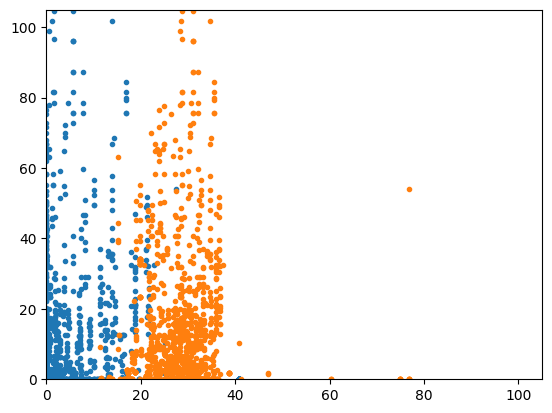

In [102]:
Q = (np.arange(0,1.02,.02))
match_dist(df.rs_value,df.Value,Q)
plt.ylim(0,105)
plt.xlim(0,105)
plt.scatter(match_dist(df.rs_value,df.Value,Q)[0],df.Value,marker='.')
plt.scatter(df.rs_value,df.Value,marker='.')
#df.rs_value.quantile(Q).values

In [95]:
def match_dist(target,reference,Q):
    tdist = target.quantile(Q).values
    rdist = reference.quantile(Q).values
    method = 'linear'    
    i,j = 0,Q.size  
    f = sp.interpolate.interp1d(tdist[i:j],Q[i:j],kind=method,bounds_error = False,fill_value = (0,1))    
    # --- fit an inverse model to Y; ie Y = g(Q). 
    k,l = 0,Q.size  
    g = sp.interpolate.interp1d(Q[k:l],rdist[k:l],kind=method,bounds_error=False)
    # --- given the functions f and g, the required adjustment is g(f(x)) ----------------
    
    return(
        g(f(target)),g,f
        )

In [193]:
xy.groupby('GEMS Station Number').mean().Value.min()


1.0

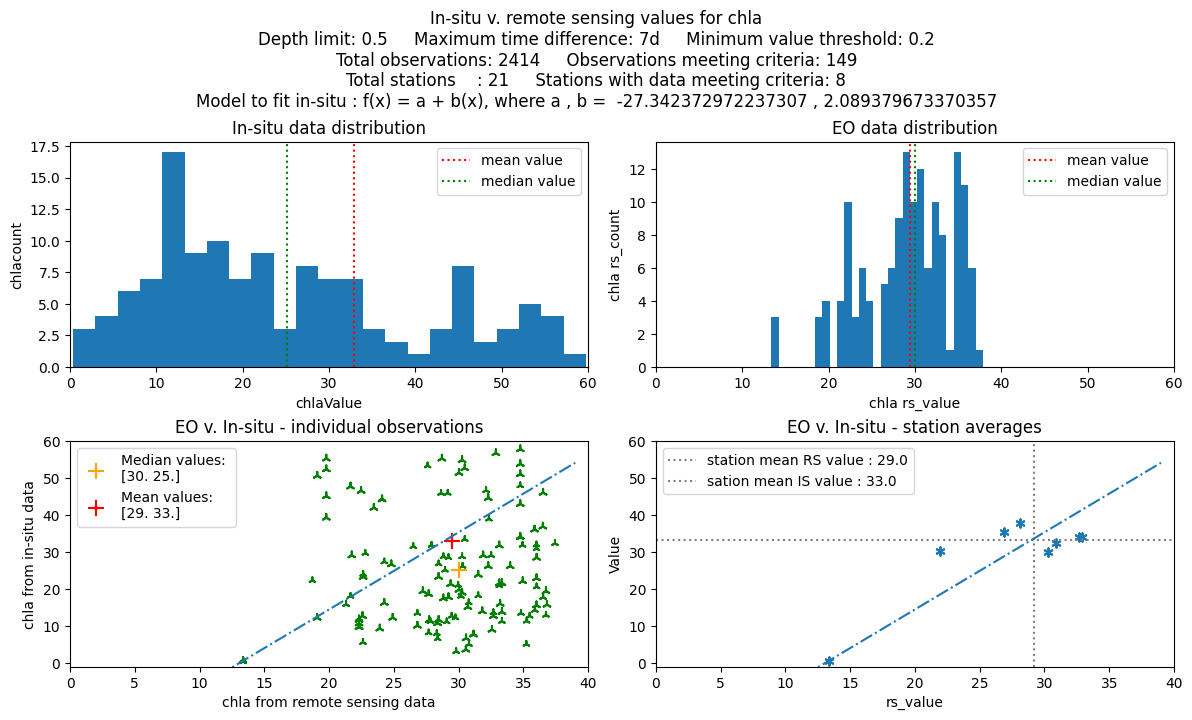

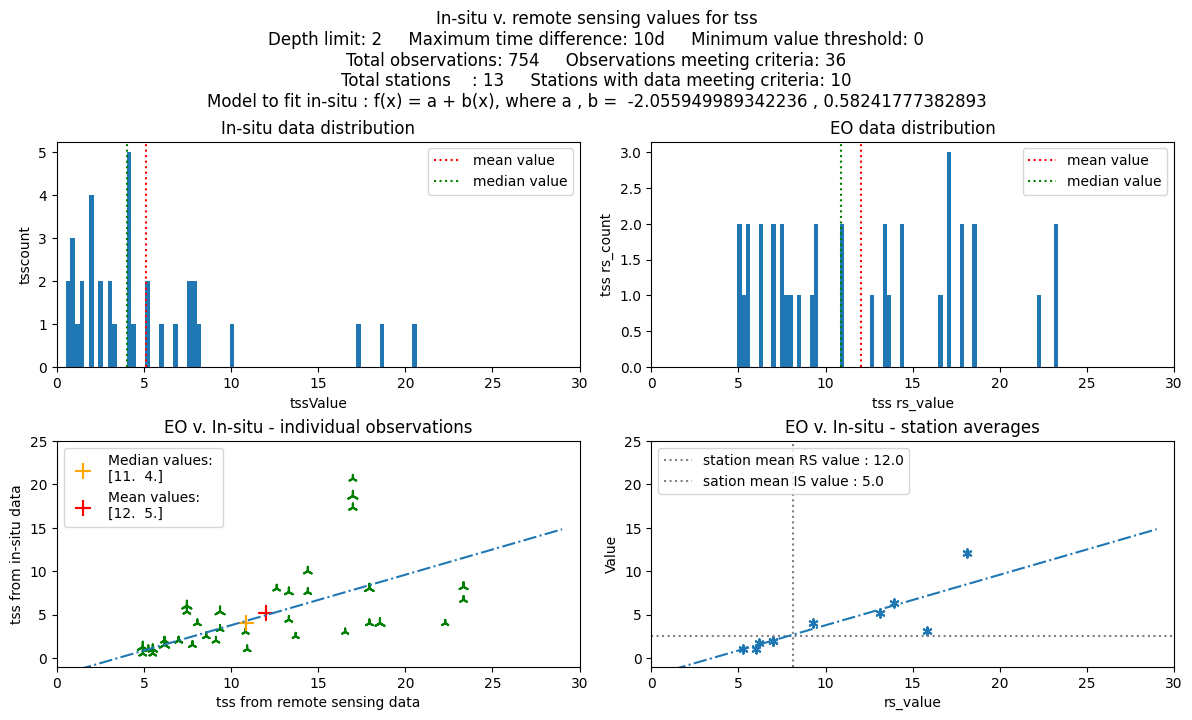

In [203]:
for var  in 'chla','tss':
    filename = '/home/jovyan/deafrica_water_quality/wq_results/WP22C_'+var+'.csv'
    df = pd.read_csv(filename)
    cm = 1/2.54

    fig, axes = plt.subplots(2,2,sharex=False, sharey=False, layout="constrained")    
    fig.set_size_inches(30*cm,18*cm)

        
    
    if var == 'chla':
        xmax = 40;  ymax = 60
        depthlimit = 0.5
        condition_f = True #df['GEMS Station Number'] != 'ZAF00018'
        condition_f = ~df['Station Identifier'].str.contains('Pelagic')
        timedeltalimit = '7d'
        minvaluelimit  = .2
    if var == 'tss':
        xmax = 30;  ymax = 25
        depthlimit = 2
        condition_f = True #df['GEMS Station Number'] != 'ZAF00018'
        timedeltalimit = '10d'
        minvaluelimit  = 0

    condition_a = (pd.notnull(df.rs_value))
    condition_b = (df.Depth <= depthlimit   )
    condition_c = (df.Value >=  minvaluelimit    )
    condition_d = (df.Value <  1000000)
    condition_e = True #df['GEMS Station Number'] != 'ZAF00017'
    condition_g = True #df['GEMS Station Number'] != 'ZAF00023'
    condition_e = (df.timedelta < timedeltalimit)
    
    
    
    
    xy    = df.loc[(
                    condition_a & condition_b & condition_c & condition_d &\
                    condition_e & condition_f & condition_g\
                   ),['rs_value','Value','Depth','GEMS Station Number']]
    
    y0 = xy.groupby('GEMS Station Number').Value.mean().min()
    y1 = xy.groupby('GEMS Station Number').Value.mean().mean()
    x0 = xy.groupby('GEMS Station Number').rs_value.mean().min()
    x1 = xy.groupby('GEMS Station Number').rs_value.mean().mean()
    if var == 'chla':
        pass
        #x0 = y0 = 0
    b = (y1-y0)/(x1-x0)
    a = y0 - b*x0
    
    
    meds  = [xy.rs_value.median(),xy.Value.median()]
    means  = [xy.rs_value.mean(),xy.Value.mean()]
    rescale = means[1]/meds[0]

    station_count = df['GEMS Station Number'].unique().size
    useful_station_count = xy['GEMS Station Number'].unique().size
    total_obs_count = df.Value.size
    useful_obs_count = xy.shape[0]

    fig.suptitle('In-situ v. remote sensing values for '
                 +var+
                 '\nDepth limit: '+str(depthlimit)+
                 '     Maximum time difference: '+str(timedeltalimit)+
                 '     Minimum value threshold: '+str(minvaluelimit)+
                 '\nTotal observations: '+str(total_obs_count)+
                 '     Observations meeting criteria: '+str(useful_obs_count)+
                 '\nTotal stations    : '+str(station_count)+
                 '     Stations with data meeting criteria: '+str(useful_station_count)+
                 '\nModel to fit in-situ : f(x) = a + b(x), where a , b =  '+str(a)+' , '+str(b)
                )
    
    
    axis  = axes[0,0]
    axis.hist(xy.Value,bins=75)
    axis.axvline(xy.Value.mean(),label='mean value',color='red',linestyle=':')
    axis.axvline(xy.Value.median(),label='median value',color='green',linestyle=':')
    axis.set_xlabel(var+'Value')
    axis.set_ylabel(var+'count')
    axis.set_title('In-situ data distribution')
    axis.set_xlim(0,max(xmax,ymax))  #that's correct
    axis.legend()
    
    axis  = axes[0,1]
    axis.hist(xy.rs_value,bins=75)
    axis.axvline(xy.rs_value.mean(),label='mean value',color='red',linestyle=':')
    axis.axvline(xy.rs_value.median(),label='median value',color='green',linestyle=':')
    axis.set_xlabel(var+' rs_value')
    axis.set_ylabel(var+' rs_count')
    axis.set_title('EO data distribution')
    axis.set_xlim(0,max(xmax,ymax))
    axis.legend()
    
    
    axis  = axes[1,0]
    axis.set_xlabel(var+' from remote sensing data')
    axis.set_ylabel(var+' from in-situ data')
    axis.set_title('EO v. In-situ - individual observations')
    axis.set_xlim(0,xmax)
    axis.set_ylim(-1,ymax)
    
    
    axis.scatter(xy.rs_value,xy.Value,marker=(3,2),s=(xy.Depth+1)*20,color='green')
#    axis.scatter(xy.rs_value.mean(),xy.Value.mean(),marker=(4,2),s=100,color='red')
    axis.scatter(meds[0],meds[1],marker=(4,2),s=100,color='orange',label='Median values: \n'+str(np.round(meds)))
    axis.scatter(means[0],means[1],marker=(4,2),s=100,color='red',label='Mean values: \n'+str(np.round(means)))
    axis.plot(a + b * np.arange(0,xmax,1),linestyle='-.')

    axis.legend(loc='upper left')
    
    axis  = axes[1,1]
    axis.set_title('EO v. In-situ - station averages')
    axis.set_xlabel('rs_value')
    axis.set_ylabel('Value')
    axis.set_ylim(-1,ymax)
    axis.set_xlim(0,xmax)
    axis.scatter(
        xy.groupby('GEMS Station Number')['rs_value'].mean(),
        xy.groupby('GEMS Station Number')['Value'].mean(),
        marker=(6,2))
    meds = [xy.groupby('GEMS Station Number')['rs_value'].mean().median(),\
            xy.groupby('GEMS Station Number')['Value'].mean().median()]
    axis.axvline(meds[0],label='station mean RS value : '+str(np.round(means[0])),linestyle=':',color='grey')    
    axis.axhline(meds[1],label='sation mean IS value : '+str(np.round(means[1])),linestyle=':',color='grey')        

    axis.plot(a + b * np.arange(0,xmax,1),linestyle='-.')
    axis.legend(loc='upper left')

    if False:
        axis  = axes[1,1]
        axis.set_title('median/mean re-scaling')
        axis.set_xlim(0,xmax)
        axis.set_ylim(0,ymax)
        axis.set_xlabel(var+' from remote sensing data')
        axis.set_ylabel(var+' from in-situ data')
        axis.scatter(xy.rs_value*rescale,xy.Value,marker=(3,2),s=(xy.Depth+1)*20,color='green')
        axis.scatter(xy.rs_value.mean()*rescale,xy.Value.mean(),marker=(4,2),s=100,color='red')
        axis.scatter(meds[0]*rescale,meds[1],marker=(4,2),s=100,color='orange',label='Median values: \n'+str(np.round(meds)))
        axis.scatter(means[0]*rescale,means[1],marker=(4,2),s=100,color='red',label='Mean values: \n'+str(np.round(means)))
        axis.legend()
    
        axis  = axes[1,2]
        
        dfg = df.groupby('GEMS Station Number')['Value'].quantile(np.arange(0,1.1,0.1))
        
        axis.set_title('GEMS Station value distributions')
        axis.set_ylabel('Chla')
        axis.set_xlabel('Quantile of values')
        axis.set_ylim(0,200)
        
        
        for site in dfg.loc[:,0].keys():
            axis.plot(np.arange(0,1.1,0.1),dfg.loc[site,0:10],label='',linestyle=':')
        axis.legend()
        
        # ------------------- third row ; distribution based matching -------------------
        # first graph, adjust based on the full dataset
        axis = axes[2,0]
        Q = (np.arange(0,1.05,.05))
        x0,f0,g0 = match_dist(df.rs_value,df.Value,Q)
        
        axis.set_ylim(0,ymax)
        axis.set_xlim(0,xmax)
        axis.set_title('EO v. insitu after matching distributions \n (full dataframe)')
        axis.scatter(x0,df.Value,marker='.')
        
        # second graph, adjust based on the full dataset
        axis = axes[2,1]
        Q = (np.arange(0,1.05,.05))
        x1,f1,g1 = match_dist(xy.rs_value,xy.Value,Q)
        
        axis.set_title('EO v. insitu after matching distributions \n (selected obs only)')
        axis.set_ylim(0,ymax)
        axis.set_xlim(0,xmax)
        axis.scatter(x1,xy.Value,marker='.')
        means = x1.mean(),xy.Value.mean()
        axis.axhline(means[1],linestyle='-.',color='green', label = str(means[1]))
        axis.axvline(means[0],linestyle='-.',color='orange', label = str(means[0]))
        x = np.arange(0,100,1)
        axis.plot(x,x*means[1]/means[0],linestyle='-.')
        axis.legend(loc='upper left')
        plt.show()


## Conclusions at this point:

1. Chla from EO could be transformed by f(x) = a + b(x)  a = 0, b = (33/29) to be consistent with the in-situ observations
1. TSS  from EO could be transformed by f(x) = a + b(x)  a = , b = (33/29) to be consistent with the in-situ observations
3. TSS from EO should be scaled by a factor f =  ( 9 / 11 ) to be consistent with the in-situ observations
### In-situ data are only available during the TM and OLI  era (upto 2016)

# Part C3 -  Comparisons with CGLS observations.


#### :
- Identify compartison lakes; reasonably large areas
- Load the CGLS data for 2019-2024, 100m. Revert TSI to Chla (exponential)
- Derive the landsat and sentinel-2 water quality values at 100m for the area / time; -condense to 10 day medians. Convert to trophic state.
- Save results
- Compare the two results sets
- Derive adjustment factors for Chla

In [104]:
# ---  dependencies --- 

import datacube
import numpy as np
import xarray as xr
import scipy as sp
import gc
import json
from scipy import stats
import pandas as pd     #for dates
from odc.ui import image_aspect
from deafrica_tools.plotting import rgb # used in some visualisation for debugging
dc = datacube.Datacube(app='DoinWhatImdoin') #testing what difference the 'app' value makes...

In [105]:
# --- pathnames 
# results files are stored in my space for now
results_directory = '/home/jovyan/deafrica_water_quality/wq_results/'
WP12              = '/home/jovyan/dev/deafrica_water_quality/WP1.2/'
WP22              = '/home/jovyan/dev/deafrica_water_quality/WP2.2/'
data_directory    = '/home/jovyan/dev/deafrica_water_quality/src/water_quality/data/'
all_results_filename    = 'wq_raw'
annual_results_filename  = 'annsummary'
parta_results_filename   = '22A'
partc_results_filename   = '22C'
distributions_filename = 'measurment_distributions.nc'
lookup_table_filename  = 'targ_ref_lookup.csv'
np_parameters_filename = 'normalisation_parameters.csv'
results_filename = results_directory+partc_results_filename+'_cgls_comparison.csv'


In [24]:
# --- run code for functions that are called
%run /home/jovyan/dev/deafrica_water_quality/WP2.2/_WP2.2_functions.py   
%run /home/jovyan/dev/deafrica_water_quality/WP1.2/_WQ_functions.py

In [7]:
# determine some large lakes as target areas

In [8]:
places_dict = set_spacetime_domain()

In [21]:
# --- controlling parameters and settings 
verbose = True 
test    = False
# --- the number of cells in the spatial domain (x,y) used to analyse the waterbody ; Data are resampled guided by this limit 
max_cells = 100000   
max_cells = 50000   #use this to test memory limits. Memory saving steps are going to be needed...
max_cells = 10000   #use this to test memory limits. Memory saving steps are going to be needed...
max_cells = 1000   #use this to test memory limits. Memory saving steps are going to be needed...
start, end = '2019-01-01','2024-12-31' #this is a good start interval for instrument cross-referencing

# --- get the dictionary of all possible places for analysis ---
places_dict     = set_spacetime_domain()   
process_list = ['Lake_Baringo', 
            'Senegal_StLouis', 
            'Lake_Mweru',
            'Lake_vic_turbid', 
            'Morocco', 
            'Ethiopia1of2', 
            'Ethiopia2of2', 
            'Ethiopia3of2',
            'Lake Chamo', 
            'Lake Ziway', 
            'Lake Alwassa',
            'mombasa', 
            'Lake_Nasser_nth',
            'Lake_Nasser_sth',
            'Lake_Malawi',
            'Barrage Joumine', 
            'Lake_Chilwa', 'Lake_Malombe',
            'Lake Bogoria',
            'HC_1',
            'HC_2',
            'HC_3',
            'HC_4',
            'HC_5',
            'HC_6']

process_list = [
            'HC_2',
]

In [10]:
# --- dictionaries for the non-geomedian instruments and products ...
instruments_to_use = {
    'oli_agm'  : {'use': False },
    'oli'      : {'use': True},
    'msi_agm'  : {'use': False },
    'msi'      : {'use': True},
    'tm_agm'   : {'use': False },
    'tm'       : {'use': True},
    'tirs'     : {'use': True},  
    'wofs_ann' : {'use': False },
    'wofs_all' : {'use': False },  # wofs_all will be removed as it is better to derive from wofs_ann
    }

# for the non-geomedian datasets, the build function wants to know the products ... 
#instruments_to_use = check_instrument_dates(instruments_to_use,
#                                            pd.DatetimeIndex([year1]).year[0],
#                                            pd.DatetimeIndex([year2]).year[0],False)
products = { 
                'tm_agm'  :["gm_ls5_ls7_annual"],
                'tm'      :["ls5_sr","ls7_sr"],
                'oli_agm' :["gm_ls8_annual","gm_ls8_ls9_annual"],
                'oli'     :["ls8_sr","ls9_sr"],
                'msi_agm' :["gm_s2_annual"],
                'msi'     :["s2_l2a"],
                'tirs'    :["ls5_st","ls7_st","ls8_st","ls9_st"],
                'wofs_ann':["wofs_ls_summary_annual"],
                'wofs_all':["wofs_ls_summary_alltime"],
               }

instruments,measurements,rename_dict = instruments_list(instruments_to_use) 
data_list = {}

In [11]:
geomedians_done = False
olimsi_done     = False
cgls_done       = False
dataframe_done  = False

In [22]:
# check for already done places and remove from the list.
if os.path.exists(results_filename):
    for place in process_list:
        if place in list(pd.read_csv(results_filename).place.unique()) :
            print(place+'  already done')
            if True:
                process_list.pop(process_list.index(place))


In [13]:
             
        # --- the lookup table links each measurement to a reference measurement
        lookup = pd.read_csv(data_directory+lookup_table_filename,index_col=0)
        
        # --- the distributions data has the statistical distributions of all variables, calculated on all images (not geomedians) for 2019 and 2020 over about 20 sites.
        distributions =  xr.open_dataset(WP22+distributions_filename).load(); distributions.close()
        
        # --- normalisation parameters are simple offset and scale parameters
        #     read these first into a DataFrame and then convert to a DataSet      
        np_data = pd.read_csv(data_directory+np_parameters_filename)


In [25]:
for placename in process_list:
    
    xyt,grid_resolution,cell_area, resampling_option,  year1,year2 =  \
        set_spacetime_domain(placename , start , end , max_cells = max_cells)
    if placename == 'Lake_Mweru' :
        grid_resolution = (1000,1000)
    
    #grid_resolution = (100,100)
#        set_spacetime_domain(placename,'2019-1-1', '2024-12-31')
    parameters  =    store_parameters(placename,
                                          xyt,
                                          grid_resolution,
                                          cell_area,
                                          resampling_option,
                                          year1,
                                          year2)

    # --- extract the geomedian data for definition of water area"
    if not geomedians_done:
        print(placename+' - > Processing the geomedian datasets...')

        gm_years,gm_instruments_to_use = geomedian_instruments_and_years(parameters)
        # --- different years are needed for the geomedians to give a 5 year interval
        gm_parameters = parameters              # --- store the parameters for reference 
        gm_parameters['year1'], gm_parameters['year2'] = gm_years[0],gm_years[1]

        # --- check the proposed years against the geomedian dataset dates ---
        gm_instruments_to_use = check_instrument_dates(gm_instruments_to_use,gm_years[0],gm_years[1],verbose=False)
        # --- get the full detail, the gm_instruments is used later, the other parts not 
        gm_instruments,gm_measurements,gm_rename_dict   = instruments_list(gm_instruments_to_use)
        
        print('... building the geomedian dataset for '+placename)
        ds_annual  =  build_agm_dataset(gm_parameters,gm_instruments_to_use)
        ds_annual  =  detect_geomedian_instruments(ds_annual)
        ds_annual  =  calculate_agm_count(ds_annual)
        WFTH       = water_frequency_threshold_high = 0.5    #this threshold targets areas that are as like as not to be water at any time.
        PWT        = permanent_water_threshold      = 0.875  #used to map annual permanent water (value arrived at through testing)
        SC         = sigma_coefficient              = 1.2    #used to map annual permanent water (value arrived at through tessting)
        ds_annual   = water_analysis(ds_annual,
               water_frequency_threshold= WFTH,
               wofs_varname             = 'wofs_ann_freq',
               permanent_water_threshold= PWT,
               sigma_coefficient        = SC,
               verbose                  = True,
               test                     = test)
        ds_annual              = WOFS_5_year_frequency(ds_annual,False)
        ds_annual['water_5yr'] = xr.where(ds_annual.wofs_5yr_freq>0.45,
                                ds_annual.wofs_5yr_freq.astype('bool'),np.nan)
        ds_annual              = geomedian_FAI(ds_annual,ds_annual.water_5yr)
        ds_annual              = geomedian_NDVI(ds_annual,ds_annual.water_5yr)
        ds_annual              = set_clearwater(ds_annual,'agm_fai','water_5yr','wofs_ann_water')


        algorithms_chla,algorithms_tsm = set_wq_algorithms(suffix='_agm')
        dummy,chla_vlist = WQ_vars(ds_annual.where(ds_annual.clearwater),
                    algorithms_chla, 
                    gm_instruments, 
                    new_dimension_name=None, 
                    new_varname=None,
                    verbose=verbose,
                    test=False)

        ds_annual[chla_vlist] = dummy[chla_vlist]
        del dummy
        gc.collect()

        dummy,tss_vlist = WQ_vars(ds_annual.where(ds_annual.clearwater),
                    algorithms_tsm, 
                    gm_instruments, 
                    new_dimension_name=None, 
                    new_varname=None,
                    verbose=verbose,
                    test=False)

        ds_annual[tss_vlist] = dummy[tss_vlist]
        del dummy
        gc.collect()

        ds_annual['chla'] = ds_annual[chla_vlist].to_array(dim = 'chla_measure')
        ds_annual['tss'] = ds_annual[tss_vlist].to_array(dim = 'tss_measure')

        
        
        for mmt in ['chla','tss']:
            vartype = mmt+'_measure'
            for varname in list(ds_annual[vartype].values):
                ds_annual[mmt].loc[{vartype :[varname]}]= \
                    harmonise_for_instrument(
                        ds_annual[mmt].loc[{vartype :[varname]}],
                        varname,
                        lookup,
                        distributions,
                        test=False)
        
        # --- remove bad variables which will otherwise cause problems with median, mean etc.
        for mmt  in np_data.loc[np_data.scale == 0].measurement.values:
            print('resetting to nan:', mmt)
            for var in ['tss','chla']:
                if mmt in ds_annual[var+'_measure']:
                    ds_annual.loc[{var+'_measure' : mmt }][var] = np.nan
        
        # Variable to variable harmonisation
        # --- add the scale and offset parameters into the dataset for simplicity in the follwoing steps
        for var in ['chla','tss']:
            measures = ds_annual[var+'_measure']
            for thing in ['scale','offset','era_factor']:
                ds_annual[var+'_'+thing] = (var+'_measure'),np_data.set_index('measurement').loc[measures,thing]
        
        for var in ['tss','chla']:
            ds_annual[var+'_h'] = \
            (((ds_annual[var] \
             * ds_annual[var+'_scale']) \
             + ds_annual[var+'_offset']) \
             * ds_annual[var+'_era_factor'])

        for var in ds_annual.data_vars :
            if not var in set(['chla','tss','tss_h','chla_h','clearwater','agm_fai','fai','water_5yr','wofs_ann_water'] ):
                ds_annual = ds_annual.drop_vars(var,errors='ignore')
        gc.collect()
        #geomedians_done = True


        
    if not  olimsi_done : 
        print(placename+' - > Processing the main datasets...')
        # confirm the instruments to use 
        instruments_to_use = check_instrument_dates(instruments_to_use,
                               pd.DatetimeIndex([parameters['xyt']['time'][0]]).year[0],
                               pd.DatetimeIndex([parameters['xyt']['time'][1]]).year[0],
                               verbose=False)

        # retreive the details of the instruments, measurements and renaming of variables
        instruments,measurements,rename_dict   = instruments_list(instruments_to_use)

        # build the datasets which are saved in a dictionary
        data_list             = build_dataset(xyt,
                                           instruments_to_use,
                                           products,
                                           measurements,
                                           grid_resolution,
                                           resampling_option,
                                           rename_dict,
                                           verbose = True)
        ds = add_vars_and_combine_datasets(data_list)
        del data_list
        gc.collect()
        


        ds = determine_water_area (ds,ds_annual)
        qa_percent_threshold = 0.2
        ds = ds.where(ds['data_qapass'] > qa_percent_threshold,drop=True)
        gc.collect()
        ds = calc_ndvi(ds,ds.water_5yr,threshold=0)
        ds = calc_fai(ds,ds.water_5yr,threshold=0)
        ds = set_clearwater(ds,'fai','water_5yr','water_ann')
        ds = apply_R_correction(ds,['msi','oli','tm'],ds.clearwater,drop=True,test=False)

        print('running wq algorithms')
        algorithms_chla,algorithms_tsm = set_wq_algorithms(suffix='')
        dummy,tsm_vlist  = WQ_vars(ds.where(ds.clearwater),
                    algorithms_tsm,  
                    instruments, 
                    new_dimension_name=None, 
                    new_varname=None, 
                    verbose=verbose,
                    test=False)
        

        # this two-step process avoids masking other variables
        ds[tsm_vlist] = dummy[tsm_vlist]
        del(dummy)
        gc.collect()

        dummy,chla_vlist = WQ_vars(ds.where(ds.clearwater),
                    algorithms_chla, 
                    instruments, 
                    new_dimension_name=None, 
                    new_varname=None,
                    verbose=verbose,
                    test=False)
        ds[chla_vlist] = dummy[chla_vlist]
        del dummy
        gc.collect()

        # condense to the key varibles before saving
        ds['chla'] = ds[chla_vlist].to_array(dim = 'chla_measure')
        ds['tss'] = ds[tsm_vlist].to_array(dim = 'tss_measure')

        for var in ds.data_vars :
            if not var in set(['chla','tss','tss_h','chla_h','clearwater','fai'] ):
                ds = ds.drop_vars(var,errors='ignore')
        gc.collect()

        
        # loop through tss and chla data arrays withing the dataset...
        # loop through the variables in each case... 
        # assign values  back into the dataset
        for mmt in 'tss','chla':
            vartype = mmt+'_measure'
            for varname in list(ds[vartype].values):
                ds[mmt].loc[{vartype :[varname]}]= \
                    harmonise_for_instrument(
                        ds[mmt].loc[{vartype :[varname]}],
                        varname,
                        lookup,
                        distributions,
                        test=False)
        
        
        # --- remove bad variables which will otherwise cause problems with median, mean etc.
        for mmt  in np_data.loc[np_data.scale == 0].measurement.values:
            print('resetting to nan:', mmt)
            for var in 'tss','chla':
                if mmt in ds[var+'_measure']:
                    ds.loc[{var+'_measure' : mmt }][var] = np.nan
        
        
        # Variable to variable harmonisation
        # --- add the scale and offset parameters into the dataset for simplicity in the follwoing steps
        for var in ['chla','tss']:
            measures = ds[var+'_measure']
            for thing in ['scale','offset','era_factor']:
                ds[var+'_'+thing] = (var+'_measure'),np_data.set_index('measurement').loc[measures,thing]
        
        
        for var in ['tss','chla']:
            ds[var+'_h'] = \
            (((ds[var] \
             * ds[var+'_scale']) \
             + ds[var+'_offset']) \
             * ds[var+'_era_factor'])
        #olimsi_done     = True
        #harmonised = True
    if not cgls_done:
        print('processing the cgls data')
        # Load trophic state and turbidity data from cgls and add a clearwater variable
        cgls_lkwq = dc.load(product=["cgls_lwq100_2019_2024"],
                              **xyt,
                              measurements=["TSI", "turbidity"],
        #                      geopolygon=bbox_geom,
                              output_crs="EPSG:6933",
                              resolution=parameters['grid_resolution'],
                           )
        cgls_lkwq['clearwater'] = ('time','y','x'), ds_annual.clearwater.sel(time=cgls_lkwq.time,method='nearest').data
        # remove the notdata values
        for var in  ["TSI",'turbidity']:
            cgls_lkwq[var] = cgls_lkwq[var].where(cgls_lkwq[var]!=float(cgls_lkwq[var].nodata))
        
        # revert the TSI measures to Chla 
        slope     = 22.4622417 
        intercept = 30.9129 + 0.53
        cgls_lkwq['chla'] = 10**((cgls_lkwq['TSI'] - intercept)/slope)
        #cgls_done = True

    if not dataframe_done :
        print('saving data frame')
        origin = parameters['xyt']['time'][0]
        a = xr.Dataset()
        
        #get the mean values for each fortnight
        m0 = cgls_lkwq.chla.resample(time='2W',origin=origin).mean()
        a['cgls'] = m0
        
        m1 = xr.DataArray(name='wqs_chla',
                          dims=('time','y','x'), 
                          coords = m0.coords, 
                          data=ds.chla_h.median(dim='chla_measure').\
                              resample(time='2W').median().\
                              sel(time=m0.time,method='nearest').values
                         )
        a['wqs']  = m1.where(~np.isnan(a['cgls']))

        results_filename = results_directory+partc_results_filename+'_cgls_comparison.csv'
        #results_filename = 'dummy.csv'
          
        df = pd.DataFrame()
        df['time']        = a.time
        df['cgls_n']      = a.cgls.count(dim=('x','y'))
        df['wqs_n']       = a.wqs.count(dim=('x','y'))
        df['cgls_mean']   = a.cgls.mean(dim=('x','y'))
        df['cgls_median'] = a.cgls.median(dim=('x','y'))
        df['wqs_mean']    = a.wqs.mean(dim=('x','y'))
        df['wqs_median']  = a.wqs.median(dim=('x','y'))
        df.insert(loc=0,column='place',value=placename)

        if not os.path.exists(results_filename) :
            df.to_csv(results_filename)
        else :
            otherresults = pd.read_csv(results_filename,index_col=0)
            otherresults.drop(otherresults.loc[otherresults.place==placename].index,inplace=True)
            pd.concat( [df , otherresults ] ).to_csv(results_filename)
        #dataframe_done = True

        

HC_2 - > Processing the geomedian datasets...
... building the geomedian dataset for HC_2

Building the Geomedian dataset:
loading data for  oli_agm ...
loading data for  msi_agm ...
loading data for  wofs_ann ...
ChlA_MERIS two-band model
ChlA_MODIS two-band model
NDSSI_RG
NDSSI_RG
NDSSI_BNIR
TI_yu
TSM_LYM_OLI
TSM_LYM_OLI
SPM_QIU
resetting to nan: ndci_msi74
resetting to nan: chla_toming_msi
resetting to nan: chla_tebbs_tm
HC_2 - > Processing the main datasets...
building the oli dataset...
... done.
building the msi dataset....
... done.
building the tm dataset ...
... done.
Data list =  dict_keys(['oli', 'msi', 'tm']) 

... instrument datasets complete

---variable -->   msi01   <-- anticipated but not found in the dataset (non-fatal)
running wq algorithms
NDSSI_RG
NDSSI_RG
NDSSI_RG
NDSSI_BNIR
TI_yu
TI_yu
TSM_LYM_OLI
TSM_LYM_OLI
TSM_LYM_ETM
SPM_QIU
SPM_QIU
ChlA_MERIS two-band model
ChlA_MODIS two-band model
ChlA_MODIS two-band model
resetting to nan: ndci_msi74
resetting to nan: chl

In [160]:
parameters


{'placename': 'Lake_Nasser_nth',
 'xyt': {'x': (32.87, 32.95),
  'y': (23.69, 23.72),
  'time': ('2019-01-01', '2024-12-31')},
 'grid_resolution': (140, 140),
 'cell_area': 0.0196,
 'resampling_option': 'nearest',
 'year1': 2019,
 'year2': 2024}

,Unnamed: 0,place,time,cgls_n,wqs_n,cgls_mean,cgls_median,wqs_mean,wqs_median
0,0,Lake_Nasser_nth,2019-01-06 00:00:00,0,0,NaN,NaN,NaN,NaN
1,1,Lake_Nasser_nth,2019-01-20 00:00:00,0,0,NaN,NaN,NaN,NaN
2,2,Lake_Nasser_nth,2019-02-03 00:00:00,1304,1303,7.439059,6.701104,50.521239,52.194082
3,3,Lake_Nasser_nth,2019-02-17 00:00:00,1122,1120,5.414777,4.552608,33.257738,32.646323
4,4,Lake_Nasser_nth,2019-03-03 00:00:00,0,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
460,150,Lake_Mweru,2024-10-06,3869,3777,9.913414,6.701104,72.951902,70.906761
461,151,Lake_Mweru,2024-10-20,3345,3273,7.527588,6.701104,87.517909,81.265407
462,152,Lake_Mweru,2024-11-03,471,469,8.248961,6.701104,79.300448,79.698416
463,153,Lake_Mweru,2024-11-17,3255,3210,8.504458,6.701104,77.278939,72.630938


In [166]:
df.loc[df.place==placename].loc[~np.isnan(df.cgls_mean)]

,Unnamed: 0,place,time,cgls_n,wqs_n,cgls_mean,cgls_median,wqs_mean,wqs_median
2,2,Lake_Nasser_nth,2019-02-03 00:00:00,1304,1303,7.439059,6.701104,50.521239,52.194082
3,3,Lake_Nasser_nth,2019-02-17 00:00:00,1122,1120,5.414777,4.552608,33.257738,32.646323
5,5,Lake_Nasser_nth,2019-03-17 00:00:00,551,549,5.204513,2.404113,34.460720,32.286853
7,7,Lake_Nasser_nth,2019-04-14 00:00:00,148,146,6.239851,2.404113,57.683086,56.283506
8,8,Lake_Nasser_nth,2019-04-28 00:00:00,791,788,3.982145,2.404113,72.445806,69.215428
...,...,...,...,...,...,...,...,...,...
141,141,Lake_Nasser_nth,2024-06-02 00:00:00,1437,1428,6.826053,6.701104,113.416887,113.273558
142,142,Lake_Nasser_nth,2024-06-16 00:00:00,1435,1429,6.692711,6.701104,92.698213,95.570585
143,143,Lake_Nasser_nth,2024-06-30 00:00:00,1433,1426,6.529597,6.701104,56.889130,54.571122
144,144,Lake_Nasser_nth,2024-07-14 00:00:00,1433,1428,6.709510,6.701104,55.374270,55.927021


## Analyse the results and determine correction factor for chla based on the cgls

In [14]:
df = pd.read_csv(results_filename)

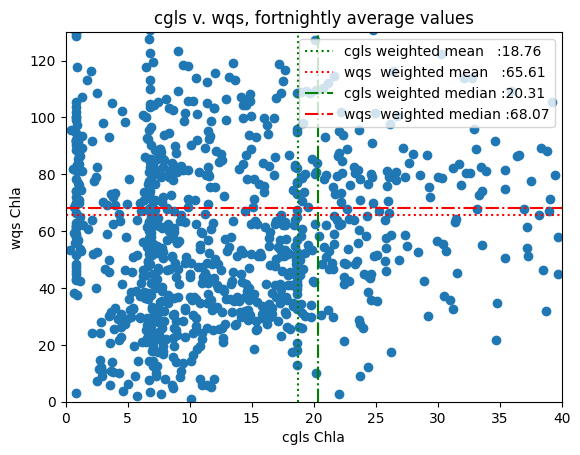

In [15]:
plt.scatter(df.cgls_mean,df.wqs_median)
wqs_overall_mean   = (df.wqs_mean * df.wqs_n).sum() / (df.wqs_n.sum())
wqs_overall_median = (df.wqs_median * df.wqs_n).sum() / (df.wqs_n.sum())
cgls_overall_mean = (df.cgls_mean * df.cgls_n).sum() / (df.cgls_n.sum())
cgls_overall_median = (df.cgls_median * df.cgls_n).sum() / (df.cgls_n.sum())
plt.axvline(cgls_overall_median,label='cgls weighted mean   :'+str(round(cgls_overall_median,2)),c='g',linestyle=':')
plt.axhline(wqs_overall_median ,label='wqs  weighted mean   :'+str(round(wqs_overall_median ,2)),c='r',linestyle=':')
plt.axvline(cgls_overall_mean,label='cgls weighted median :'+str(round(cgls_overall_mean,2)),c='g',linestyle='-.')
plt.axhline(wqs_overall_mean ,label='wqs  weighted median :'+str(round(wqs_overall_mean ,2)),c='r',linestyle='-.')
plt.legend(loc='upper right')
plt.title('cgls v. wqs, fortnightly average values')
plt.xlabel('cgls Chla')
plt.ylabel('wqs Chla')
plt.xlim(0,40)
plt.ylim(0,130)
plt.show()


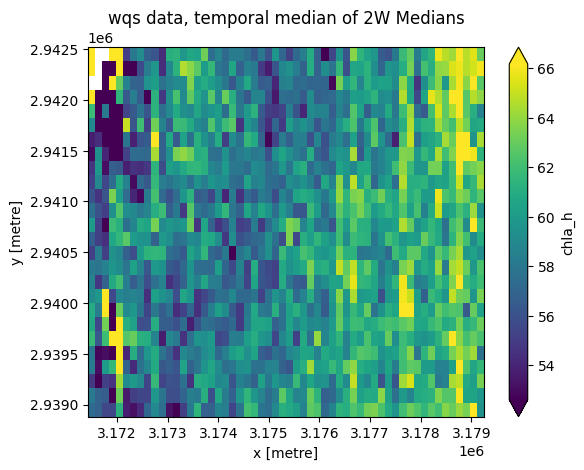

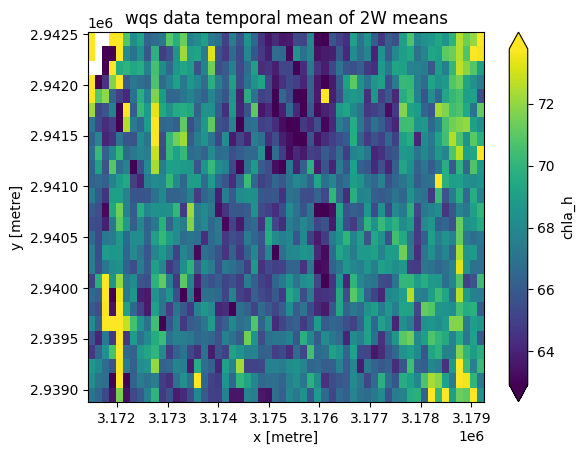

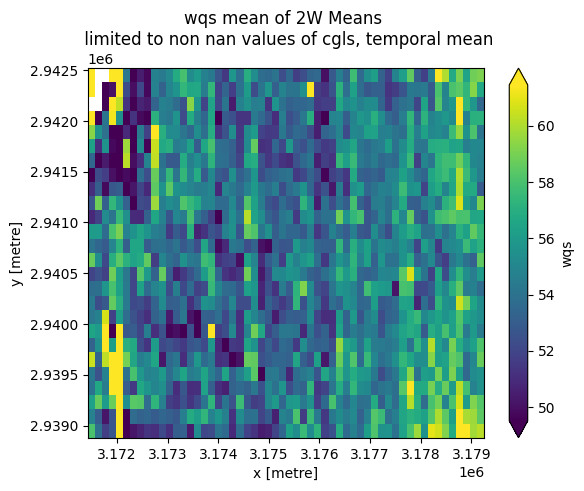

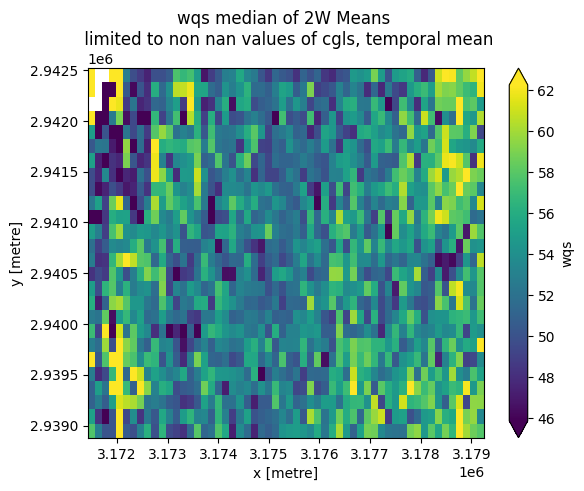

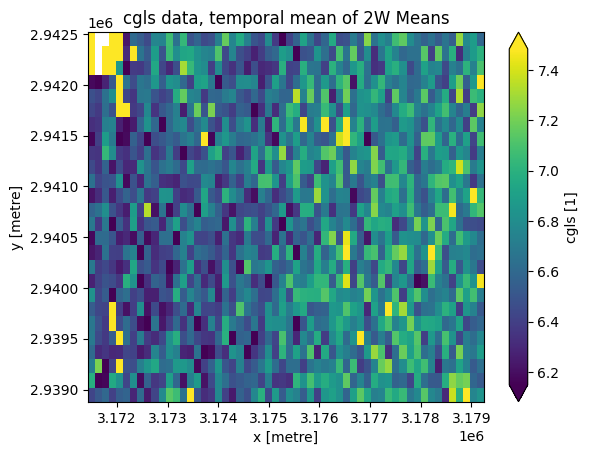

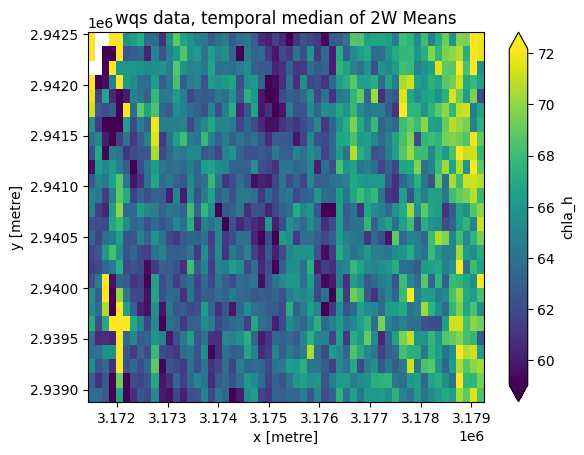

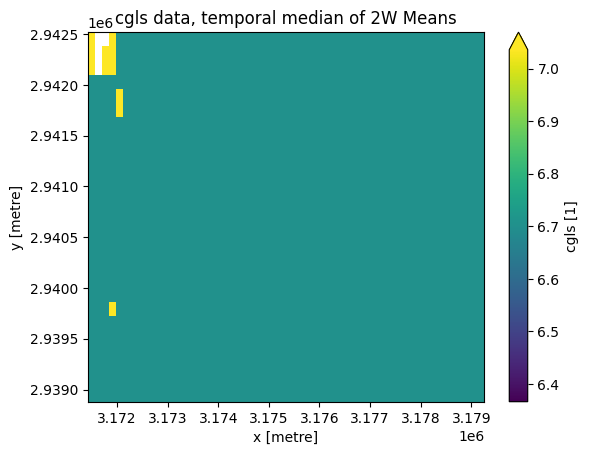

In [178]:

        ds.chla_h.median(dim='chla_measure').\
                              resample(time='2W').median().median(dim='time').plot(robust=True)
        plt.title('wqs data, temporal median of 2W Medians')
        plt.show()


        ds.chla_h.median(dim='chla_measure').\
                              resample(time='2W').mean().mean(dim='time').plot(robust=True)
        plt.title('wqs data temporal mean of 2W means')
        plt.show()

        a.wqs.where(~np.isnan(a.cgls)).mean(dim='time').plot(robust=True)
        plt.title('wqs mean of 2W Means \n limited to non nan values of cgls, temporal mean')
        plt.show()

        a.wqs.where(~np.isnan(a.cgls)).median(dim='time').plot(robust=True)
        plt.title('wqs median of 2W Means \n limited to non nan values of cgls, temporal mean')
        plt.show()

        a.cgls.mean(dim='time').plot(robust=True)
        plt.title('cgls data, temporal mean of 2W Means')
        plt.show()
        ds.chla_h.median(dim='chla_measure').\
                              resample(time='2W').mean().median(dim='time').plot(robust=True)
        plt.title('wqs data, temporal median of 2W Means')
        plt.show()
        a.cgls.median(dim='time').plot(robust=True)
        plt.title('cgls data, temporal median of 2W Means')
        plt.show()
        
    

In [59]:
df.tail()

,Unnamed: 0,place,time,cgls_n,wqs_n,cgls_mean,cgls_median,wqs_mean,wqs_median
150,150,Lake_Mweru,2024-10-06,3869,3777,9.913414,6.701104,72.951902,70.906761
151,151,Lake_Mweru,2024-10-20,3345,3273,7.527588,6.701104,87.517909,81.265407
152,152,Lake_Mweru,2024-11-03,471,469,8.248961,6.701104,79.300448,79.698416
153,153,Lake_Mweru,2024-11-17,3255,3210,8.504458,6.701104,77.278939,72.630938
154,154,Lake_Mweru,2024-12-01,1115,1098,7.850476,6.701104,77.753024,72.017817


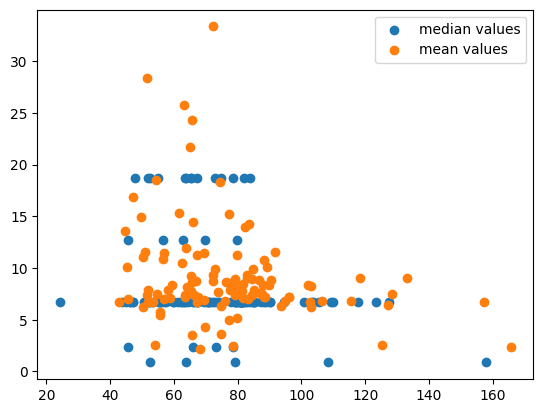

In [60]:
plt.scatter(df.wqs_median,df.cgls_median,label = "median values")
plt.scatter(df.wqs_mean,df.cgls_mean,label = "mean values")
plt.legend()
plt.show()

In [254]:
cgls_lk

{'wofs_ann': {'frequency': {'varname': 'wofs_ann_freq',
   'parameters': (True, 'other')},
  'count_clear': {'varname': 'wofs_ann_clearcount', 'parameters': (True,)},
  'count_wet': {'varname': 'wofs_ann_wetcount', 'parameters': (True,)}},
 'oli_agm': {'SR_B2': {'varname': 'oli02_agm',
   'parameters': (True, '450-510')},
  'SR_B3': {'varname': 'oli03_agm', 'parameters': (True, '530-590')},
  'SR_B4': {'varname': 'oli04_agm', 'parameters': (True, '640-670')},
  'SR_B5': {'varname': 'oli05_agm', 'parameters': (True, '850-880')},
  'SR_B6': {'varname': 'oli06_agm', 'parameters': (True, '1570-1650')},
  'SR_B7': {'varname': 'oli07_agm', 'parameters': (True, '2110-2290')},
  'smad': {'varname': 'oli_agm_smad', 'parameters': (True,)},
  'emad': {'varname': 'oli_agm_emad', 'parameters': (True,)},
  'bcmad': {'varname': 'oli_agm_bcmad', 'parameters': (True,)},
  'count': {'varname': 'oli_agm_count', 'parameters': (True,)}},
 'msi_agm': {'B02': {'varname': 'msi02_agm', 'parameters': (True, '46

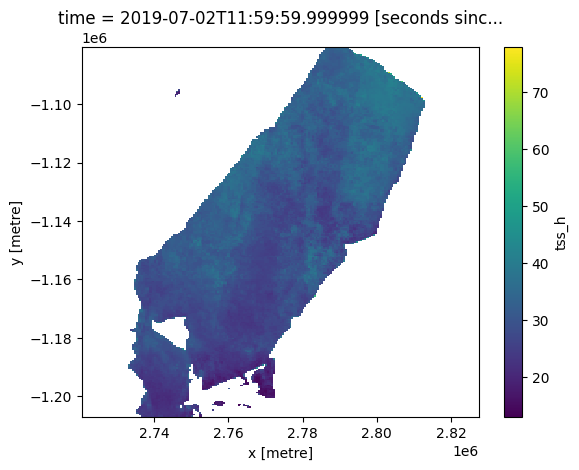

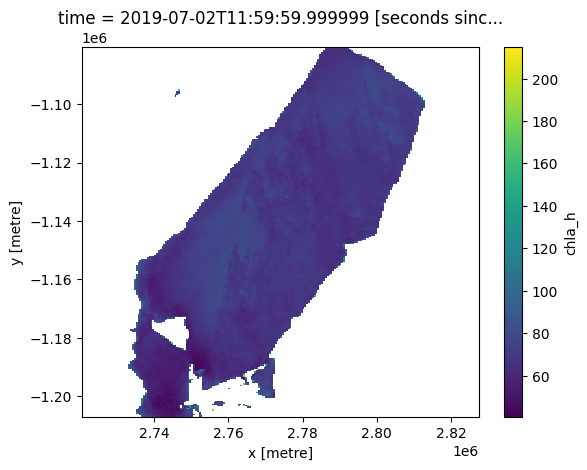

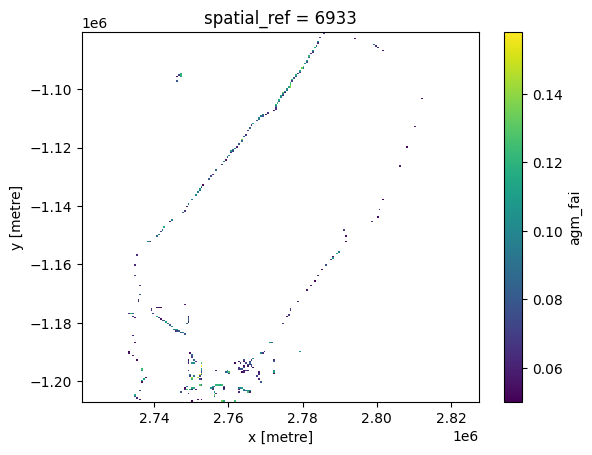

In [292]:
ds_annual.tss_h.median(dim='tss_measure').isel(time=4).plot()
plt.show()
ds_annual.chla_h.median(dim='chla_measure').isel(time=4).plot()
plt.show()
ds_annual.agm_fai.mean(dim='time').plot()


In [200]:
cgls_lkwq.chla.count(dim=('x','y'))

<xarray.DataArray 'chla' (time: 168)> Size: 1kB
array([   0,    0, 1304,  993,  601,    0,    0,  551,    0,  148,  276,
        660,  108,  138,  388,    8,   18,   29,   97,   12,   57,   18,
          5,    9,    9,    4,    3,    1,    1,   53,    0,  314,    0,
        485,  425,  531,  273,  139, 1093, 1148,   14,  679,  157,  131,
         14, 1447, 1446, 1446, 1449, 1451, 1452, 1452, 1452, 1452, 1452,
       1452, 1452, 1452,    0, 1452, 1452,    0, 1452, 1452,  621, 1452,
       1452, 1452, 1452, 1452, 1452, 1451, 1451, 1451, 1452, 1451, 1451,
       1448, 1448, 1447, 1447, 1447, 1447,    0, 1443, 1445, 1448, 1452,
       1452, 1452,    0, 1452, 1452, 1452, 1452, 1452, 1452, 1452,    0,
       1452, 1451, 1452, 1452, 1447, 1452, 1452, 1452,   52, 1452, 1452,
       1452,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0, 1452, 1452, 1452, 1452, 1452, 1452, 1452,   54, 1452,
       1451, 1448, 1447, 1446, 1444, 1441, 1437, 1434, 1428, 1433, 1433,
       1434, 1433,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0])
Coordinates:
  * time         (time) datetime64[ns] 1kB 2019-01-05T23:59:59.500000 ... 202...
    spatial_ref  int32 4B 6933
Attributes:
    units:         1
    nodata:        9969210000000000000000000000000000000
    crs:           EPSG:6933
    grid_mapping:  spatial_ref

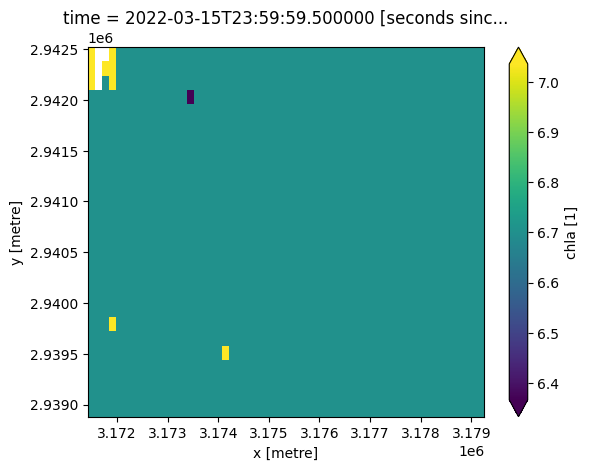

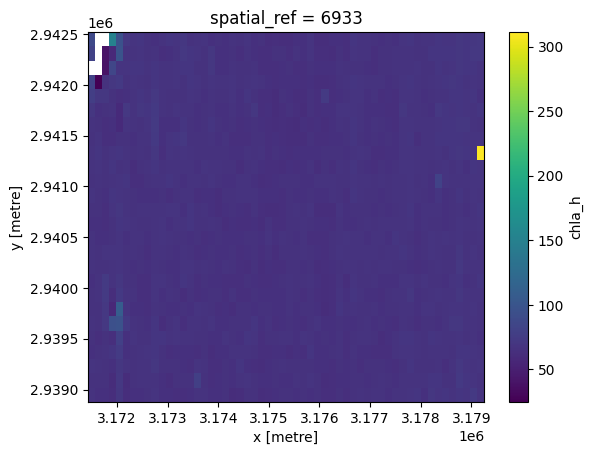

In [201]:
cgls_lkwq.chla.isel(time=70).plot(robust=True)
plt.show()
ds.chla_h.median(dim='chla_measure').where(~np.isnan(cgls_lkwq.chla.mean(dim='time'))).mean(dim='time').plot()

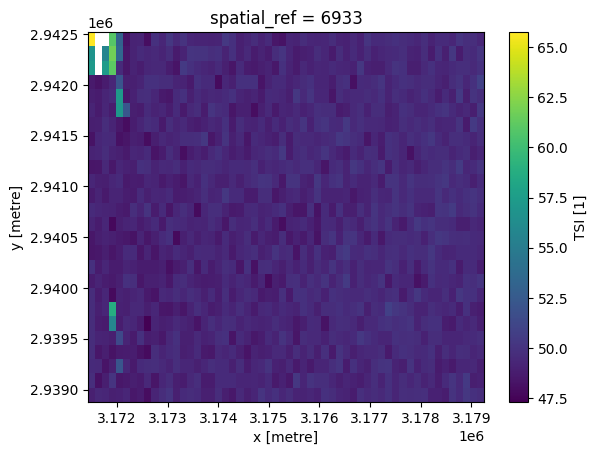

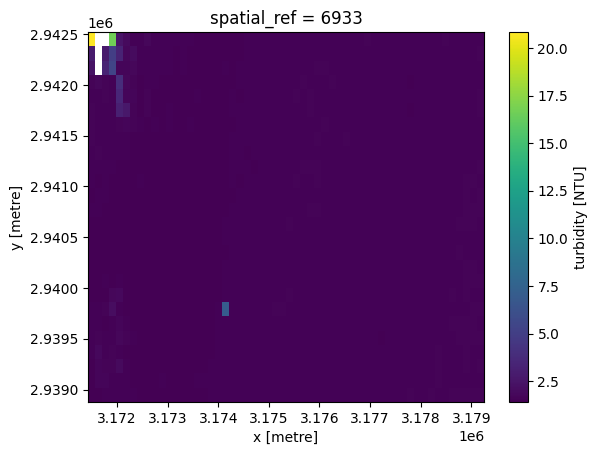

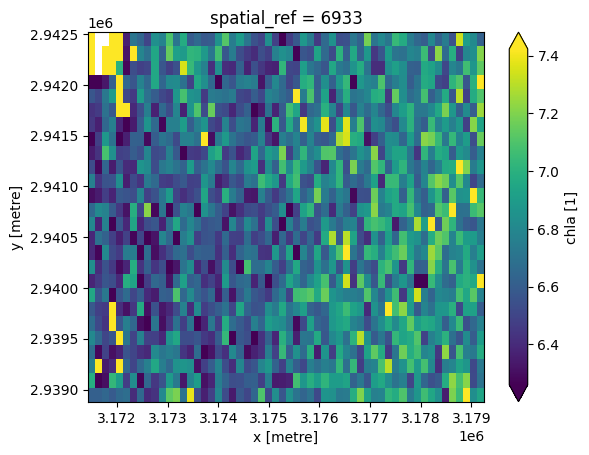

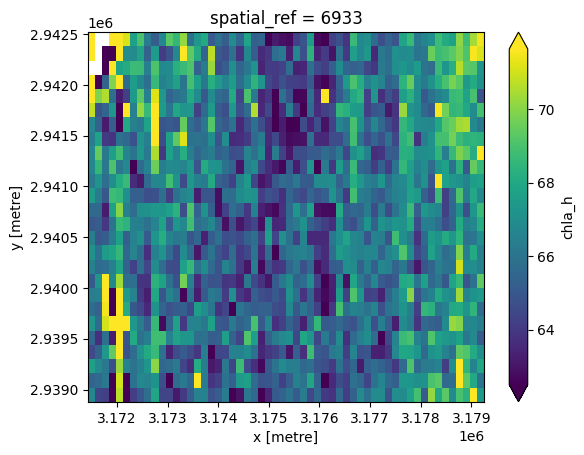

In [202]:
cgls_lkwq.TSI.mean(dim='time').plot()
plt.show()
cgls_lkwq.turbidity.mean(dim='time').plot()
plt.show()
cgls_lkwq.chla.mean(dim='time').plot(robust=True)
plt.show()
ds.chla_h.median(dim='chla_measure').mean(dim='time').plot(robust=True)

In [58]:
cgls_lkwq.time

<xarray.DataArray 'time' (time: 6)> Size: 48B
array(['2019-01-05T23:59:59.500000000', '2019-01-15T23:59:59.500000000',
       '2019-01-26T11:59:59.500000000', '2019-02-05T23:59:59.500000000',
       '2019-02-15T23:59:59.500000000', '2019-02-24T23:59:59.500000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time         (time) datetime64[ns] 48B 2019-01-05T23:59:59.500000 ... 201...
    spatial_ref  int32 4B 6933
Attributes:
    units:    seconds since 1970-01-01 00:00:00

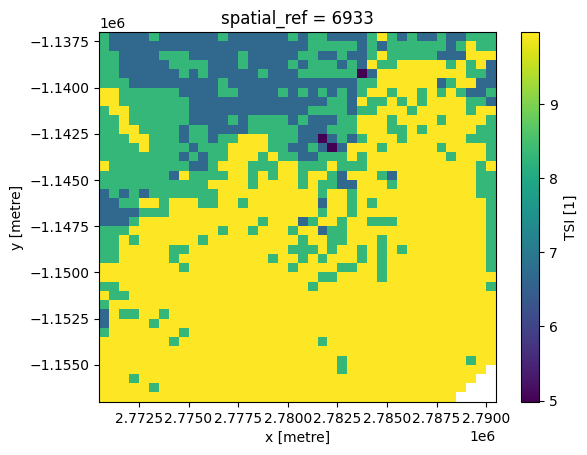

In [76]:
(cgls_lkwq.TSI.where(cgls_lkwq.clearwater==True)[:,100:140,100:140]/(10**36)).mean(dim='time').plot()

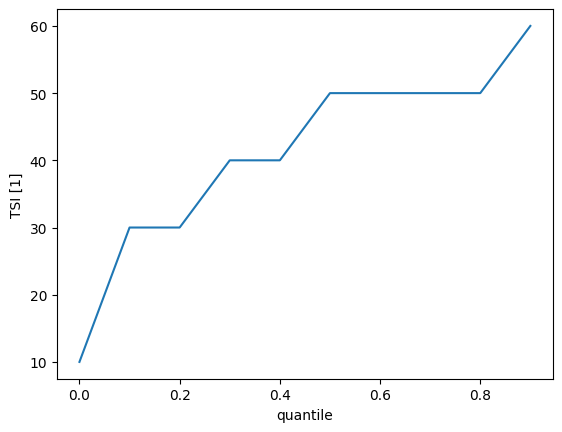

In [91]:
cgls_lkwq.TSI.where(cgls_lkwq.clearwater==True).quantile(np.arange(0,1,0.1),dim=('time','x','y')).plot()

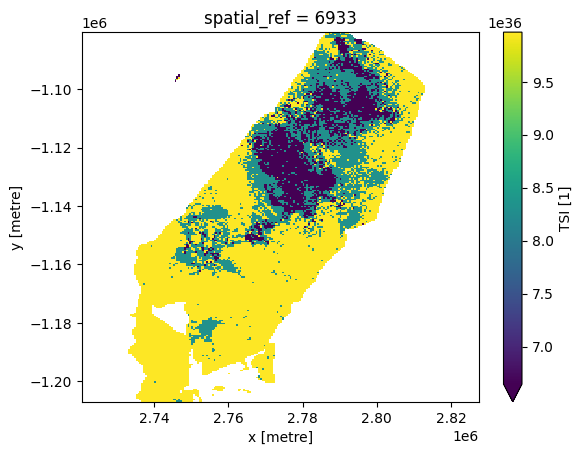

In [57]:
cgls_lkwq.TSI.where(cgls_lkwq.clearwater==True).mean(dim='time').plot(robust=True)

In [9]:
baseline_ds



                                 resolution=parameters['grid_resolution'],
                                 align=(0,0),
                                 resampling=parameters['resampling_option'],

<xarray.Dataset> Size: 194MB
Dimensions:      (time: 180, y: 489, x: 275)
Coordinates:
  * time         (time) datetime64[ns] 1kB 2006-01-05T23:59:59.500000 ... 201...
  * y            (y) float64 4kB -1.069e+06 -1.07e+06 ... -1.215e+06 -1.216e+06
  * x            (x) float64 2kB 2.732e+06 2.732e+06 ... 2.814e+06 2.814e+06
    spatial_ref  int32 4B 6933
Data variables:
    TSI          (time, y, x) float32 97MB 9.969e+36 9.969e+36 ... 9.969e+36
    turbidity    (time, y, x) float32 97MB 9.969e+36 9.969e+36 ... 9.969e+36
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref

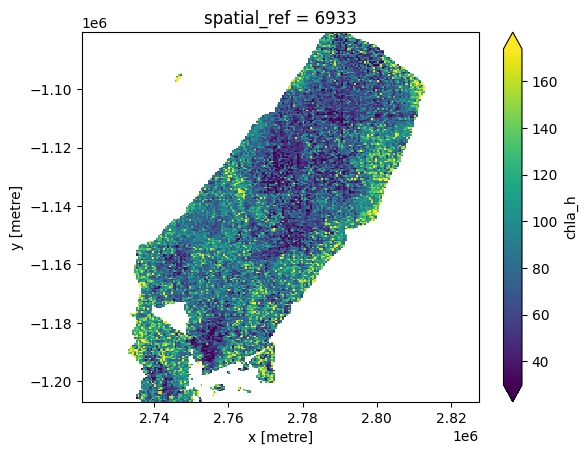

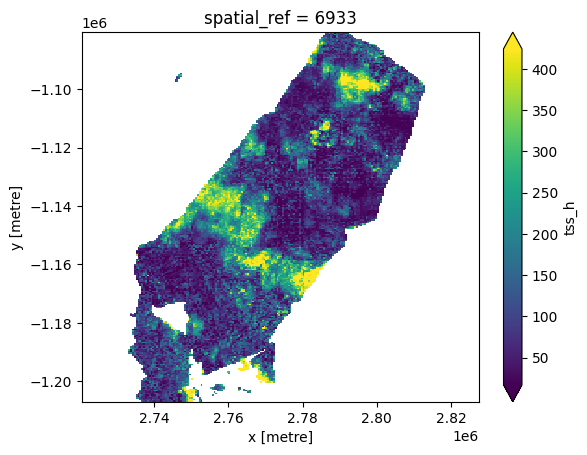

In [85]:
ds.chla_h.median(dim='chla_measure').mean(dim='time').plot(robust=True)
plt.show()
ds.tss_h.median(dim='tss_measure').mean(dim='time').plot(robust=True)

In [36]:
ds_annual


<xarray.Dataset> Size: 152MB
Dimensions:              (time: 11, y: 253, x: 214)
Coordinates:
  * time                 (time) datetime64[ns] 88B 2014-07-02T11:59:59.999999...
  * y                    (y) float64 2kB -1.207e+06 -1.206e+06 ... -1.081e+06
  * x                    (x) float64 2kB 2.721e+06 2.721e+06 ... 2.827e+06
    spatial_ref          int32 4B 6933
Data variables: (12/46)
    oli02_agm            (time, y, x) float64 5MB 215.0 221.0 ... 270.0 250.0
    oli03_agm            (time, y, x) float64 5MB 446.0 458.0 ... 500.0 489.0
    oli04_agm            (time, y, x) float64 5MB 396.0 407.0 ... 465.0 432.0
    oli05_agm            (time, y, x) float64 5MB 2.242e+03 ... 2.318e+03
    oli06_agm            (time, y, x) float64 5MB 1.531e+03 ... 1.645e+03
    oli07_agm            (time, y, x) float64 5MB 749.0 766.0 ... 915.0 846.0
    ...                   ...
    oli_agm_fai          (time, y, x) float64 5MB nan nan nan ... nan nan nan
    agm_fai              (time, y, x) float64 5MB nan nan nan ... nan nan nan
    msi_agm_ndvi         (time, y, x) float32 2MB nan nan nan ... nan nan nan
    oli_agm_ndvi         (time, y, x) float64 5MB nan nan nan ... nan nan nan
    agm_ndvi             (time, y, x) float64 5MB nan nan nan ... nan nan nan
    clearwater           (time, y, x) bool 596kB False False ... False False
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref

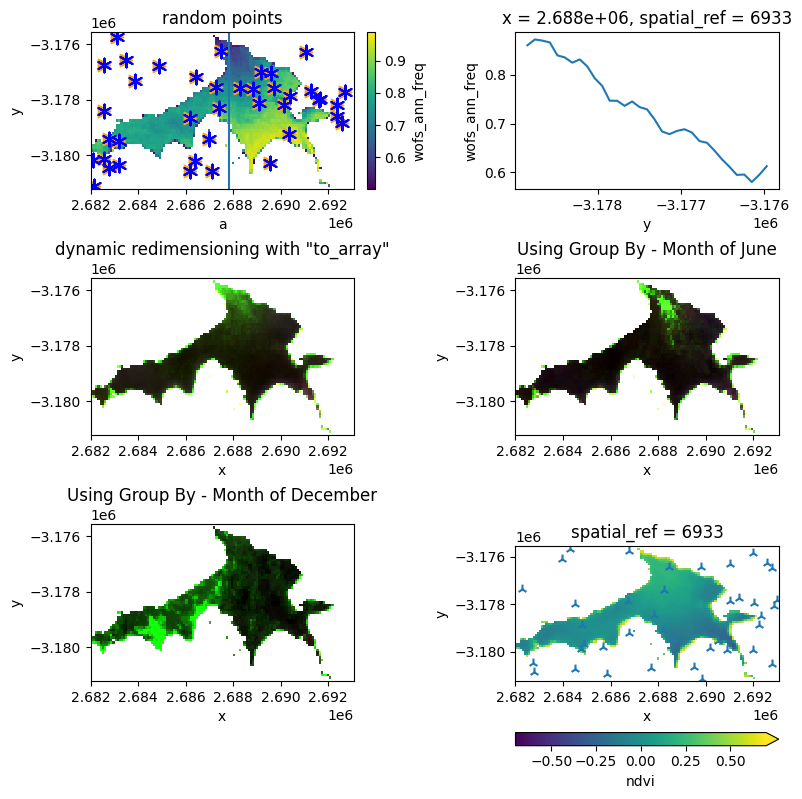

In [670]:

# demonstratnig select to pull out the values nearest to a sequence of x,y, coords (in this case a line)
cm = 1/2.54
fig, axes = plt.subplots(1,2,sharex=False, sharey=False, layout="constrained")    
fig.set_size_inches(20*cm,20*cm)
#plt.subplots(figsize=(20*cm,10*cm))
axis  = axes[0, 0]
ds.wofs_ann_freq.mean(dim='time').plot(ax=axis)
axis.set_xlabel('a')
axis.set_title('random points')

axis.scatter(data_x, data_y, s=80, c='orange', marker=">")
axis.scatter(data_x, data_y, s=8, c='black', marker=".")
axis.scatter(data_x, data_y, s=100, c='blue', marker=(6,2))

axis.axvline(geopoints.geometry.x[25])

axis = axes[0,1]
ds.sel(x=geopoints.geometry.x[25],method='nearest').mean(dim='time')['wofs_ann_freq'].plot(ax=axis)

axis = axes[1,0]
ds[['oli01','oli02','oli03','oli04','oli05']].to_array('oli').median(dim='time').sel(oli=['oli04','oli05','oli02']).plot.imshow(
    #vmin=0,
    #vmax=400,
    robust=True,
    ax=axis
    )
axis.set_title('dynamic redimensioning with "to_array"')
axis.set_axis_on()

axis = axes[1,1]
ds[['oli01','oli02','oli03','oli04','oli05']].to_array('oli').\
    groupby('time.month').\
    median(dim='time').\
    sel(month=6,oli=['oli04','oli05','oli02']).\
    plot.imshow(robust=True,ax=axis)
axis.set_title('Using Group By - Month of June')

axis = axes[2,0]
ds[['oli01','oli02','oli03','oli04','oli05']].to_array('oli').\
    groupby('time.month').\
    median(dim='time').\
    sel(month=12,oli=['oli04','oli05','oli02']).\
    plot.imshow(robust=True,ax=axis)
axis.set_title('Using Group By - Month of December')

axis = axes[2, 1]
ds.ndvi.mean(dim='time').plot(ax=axis,vmin=-0.7,vmax=0.7,cbar_kwargs=cbar_kwargs)
geopoints.plot(ax=axis, markersize=50, marker=('2'))
plt.show()


plt.show()